# ML Homework 3 Guide

1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW3.ipynb" to "HW3_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together

# [HW 3] Customize the ANN

1. Load dataset resulted from ML3_Code2 (FeatureSelected) and create corresponding labels referring to ML5_Code1.

2. Design and train a customized ANN model according to the following instructions:

- Set the learning rate to 0.01.
- Set the number of hidden layers to 3.
- Set the number of neurons in the first hidden layer to 15.
- Set the number of neurons in the second hidden layer to 10.
- Set the number of neurons in the third hidden layer to 5.
- Set the number of training epochs to 300.
- Set the activation function differently from the ML5 code by referring to the link provided in the code. (Few functions may not work due to compatibility issues, please try other functions in that case.)
- Set the loss function and optimization algorithm differently from the ML5 code by referring to the link provided. (Few functions may not work due to compatibility issues, please try other functions in that case.)

3. Plot a graph of the training process (Loss, Accuracy) at the end.

In [9]:
# Start with importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Import 'Tensorflow' pakage
import tensorflow as tf
from tensorflow import keras

In [10]:
# Check if a GPU(in Google server) is allocated
device_name = tf.test.gpu_device_name()
print('Found GPU at: {}'.format(device_name))

Found GPU at: 


In [8]:
# Acess to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
FeatureSelected = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/HW/FeatureSelected.csv', header=None)
FeatureSelected = FeatureSelected.T
FeatureSelected.shape

(360, 30)

In [12]:
# Standardize feature values
from sklearn.preprocessing import StandardScaler
FeatureSelected_std = StandardScaler().fit_transform(FeatureSelected)

# Split Normal and Abnormal sets
NoOfData = int(FeatureSelected_std.shape[0]/2)

NormalSet = FeatureSelected_std[:NoOfData,:]
AbnormalSet = FeatureSelected_std[NoOfData:,:]
NormalSet.shape, AbnormalSet.shape

((180, 30), (180, 30))

In [13]:
# Train/Test split
from sklearn.model_selection import train_test_split

TestData_Ratio = 0.2

TrainData_Nor, TestData_Nor = train_test_split(NormalSet, test_size=TestData_Ratio, random_state=77)
TrainData_Abn, TestData_Abn = train_test_split(AbnormalSet, test_size=TestData_Ratio, random_state=77)

In [14]:
# One-hot labels
TrainLabel_Nor = np.zeros((TrainData_Nor.shape[0],2))
TrainLabel_Abn = np.ones((TrainData_Abn.shape[0],2))
TestLabel_Nor = np.zeros((TestData_Nor.shape[0],2))
TestLabel_Abn = np.ones((TestData_Abn.shape[0],2))

TrainLabel_Nor[:,0] = 1
TrainLabel_Abn[:,0] = 0
TestLabel_Nor[:,0] = 1
TestLabel_Abn[:,0] = 0

In [15]:
# Combine data
TrainData = np.concatenate([TrainData_Nor,TrainData_Abn],axis=0)
TestData = np.concatenate([TestData_Nor,TestData_Abn],axis=0)

TrainLabel = np.concatenate([TrainLabel_Nor,TrainLabel_Abn],axis=0)
TestLabel = np.concatenate([TestLabel_Nor,TestLabel_Abn],axis=0)

In [16]:
# Hyperparameters
learningRate = 0.01
Epoch = 300
H1=15
H2=10
H3=5
# Build customized ANN model
def ANN_model(input_data):

    keras.backend.clear_session()
    model = keras.Sequential()

    model.add(keras.layers.InputLayer(input_shape=(input_data.shape[1],)))
    # Hidden Layer 1
    model.add(keras.layers.Dense(H1, activation='tanh'))
    # Hidden Layer 2
    model.add(keras.layers.Dense(H2, activation='tanh'))
    # Hidden Layer 3
    model.add(keras.layers.Dense(H3, activation='tanh'))
    # Output Layer
    model.add(keras.layers.Dense(2, activation='softmax'))

    # Compile model
    model.compile(
        optimizer = keras.optimizers.SGD(learning_rate=learningRate),
        loss = keras.losses.MeanSquaredError(),
        metrics = ['accuracy'])

    return model

In [17]:
# Create model
AnnModel = ANN_model(TrainData)
# Check architecture
AnnModel.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 692 (2.70 KB)

 Trainable params: 692 (2.70 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train model
tf.random.set_seed(777)
TrainingHistory = AnnModel.fit(TrainData,TrainLabel,epochs = Epoch,verbose = 1)

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4489 - loss: 0.2918  
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8890 - loss: 0.1401 
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9769 - loss: 0.0822 
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9861 - loss: 0.0571 
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9861 - loss: 0.0436 
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9908 - loss: 0.0353 
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0296 
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0255 
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0224 
Epoch 10/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0200 
Epoch 11/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0180 
Epoch 12/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - lo

In [19]:
#Check the training process (Loss, Accuracy)
Loss, Accuracy = AnnModel.evaluate(TestData, TestLabel, verbose=0)
print("Test Loss:", Loss)
print("Test Accuracy:", Accuracy)

Test Loss: 0.005988976452499628
Test Accuracy: 0.9861111044883728


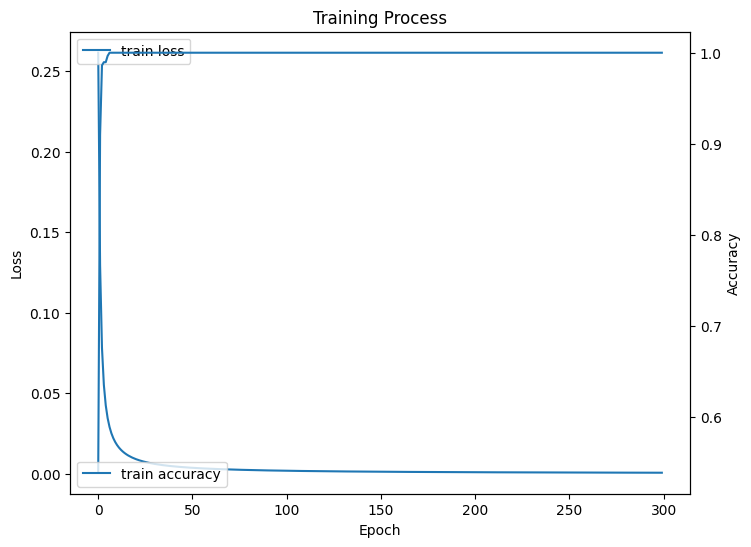

In [20]:
# Plot training process
fig, loss_ax = plt.subplots(figsize=(8,6))
acc_ax = loss_ax.twinx()

loss_ax.plot(TrainingHistory.history['loss'], label='train loss')
loss_ax.set_xlabel('Epoch')
loss_ax.set_ylabel('Loss')
loss_ax.legend(loc='upper left')

acc_ax.plot(TrainingHistory.history['accuracy'], label='train accuracy')
acc_ax.set_ylabel('Accuracy')
acc_ax.legend(loc='lower left')

plt.title("Training Process")
plt.show()

## ML5 and ML6 Summary and Deliverables

Answer the following questions for your achievements

### Q1. Please summarize ML5 and ML6.

---

**ML5 Summary:**

ML5 classifies machine conditions using selected statistical features and an ANN. The top 30 features are standardized, split into training (80%) and testing (20%) sets, and one-hot encoded ([1,0] = normal, [0,1] = abnormal). A Keras ANN with two ReLU hidden layers and a softmax output is trained for 200 epochs using Adam optimizer. Model performance is evaluated via accuracy and loss, then saved for future use.

---
**ML6 Summary:**

ML6 detects faults from raw acceleration signals using CNNs. Vibration data is converted to spectrograms via STFT, reshaped for CNN input, and one-hot encoded. The CNN includes convolution, max-pooling, flatten, and dense layers, trained for 1000 epochs. Performance is evaluated using accuracy, precision, recall, F1 score, and confusion matrix. The trained model is saved for predictions.

---

### Q2. What skills did you have to develop to accomplish this project?

---

1. Data preprocessing and feature selection

2. Neural network and CNN model design and training

3. Performance evaluation and model saving/loading

---

### Q3. What aspects of this project were the most beneficial for your learning?

---



*  Applying machine learning techniques to real sensor data

*   Understanding ANN and CNN architectures and training processes

*   Converting raw signals into meaningful features for classification






---

### Q4. What challenges did you encounter in completing the project?

---

* Handling and preprocessing large, noisy datasets

* Designing and tuning ANN and CNN architectures for accurate classification

* Managing long training times and avoiding overfitting

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

* Applied data normalization, feature selection, and one-hot encoding to clean and organize data

* Experimented with different network architectures, activation functions, and hyperparameters

* Used proper train-test splits, early stopping, and evaluation metrics to ensure model reliability

---